In [ ]:
import os
import kagglehub
import shutil

path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
print("Fichiers téléchargés dans :", path)

# Dossier de destination
dest = "data"
#os.makedirs(dest, exist_ok=True)

# Copier tous les fichiers du dossier téléchargé vers /data
#for fichier in os.listdir(path):
#    src_file = os.path.join(path, fichier)
#    dst_file = os.path.join(dest, fichier)
#    shutil.copy2(src_file, dst_file)

print("Fichiers copiés dans :", dest)

Fichiers téléchargés dans : /home/onyxia/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques
Fichiers copiés dans : data


In [ ]:
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')

In [ ]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
df_train.isna().sum().sort_values(ascending=False).head(25)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
BldgType           0
Neighborhood       0
LandSlope          0
LotConfig          0
Condition1         0
dtype: int64

In [ ]:
df_train.select_dtypes(exclude=['bool','object']).isna().sum().sort_values(ascending=False)

LotFrontage      259
GarageYrBlt       81
MasVnrArea         8
LotArea            0
MSSubClass         0
Id                 0
OverallCond        0
OverallQual        0
YearRemodAdd       0
YearBuilt          0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
BsmtFinSF1         0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
1stFlrSF           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [ ]:
df_train[['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu']].describe()

,PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu
count,7,54,91,281,588,770
unique,3,4,2,4,3,5
top,Gd,Shed,Grvl,MnPrv,BrkFace,Gd
freq,3,49,50,157,445,380


In [ ]:
df_train=df_train.select_dtypes(exclude='number').fillna('None')

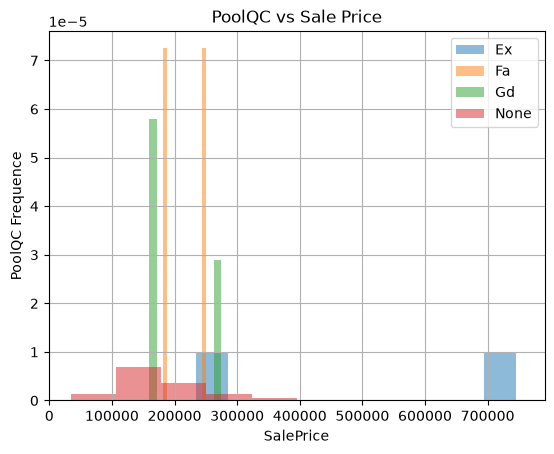

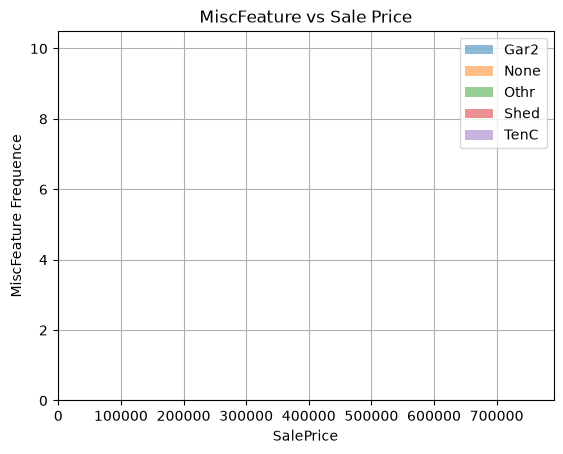

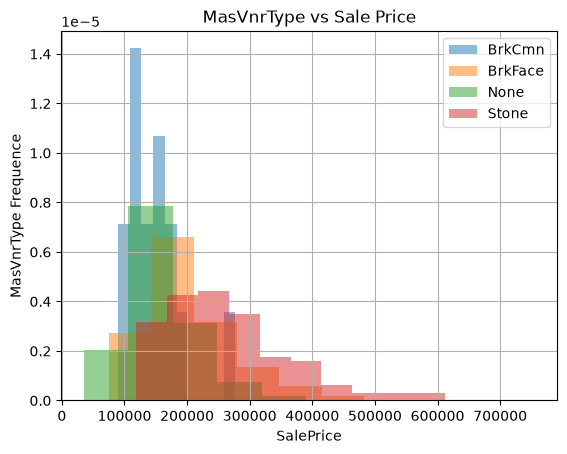

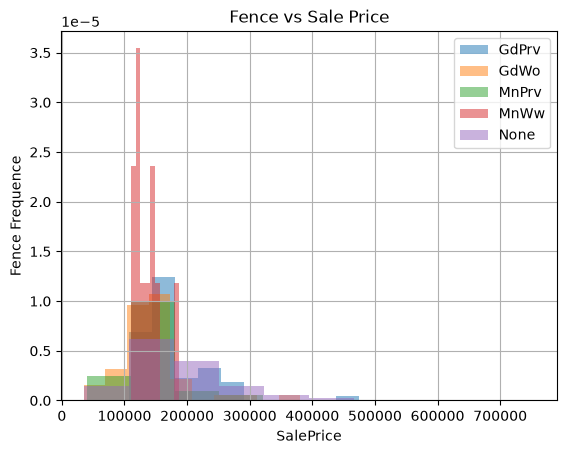

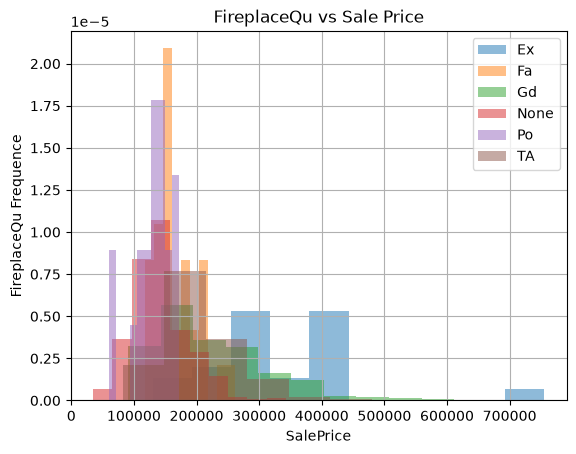

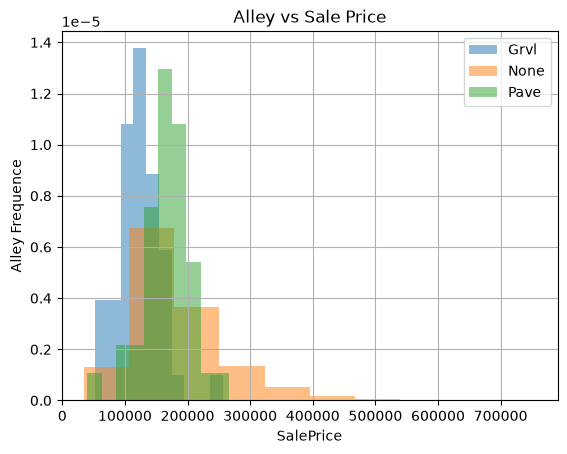

In [ ]:
Category={'PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu'}
for cat in Category:
    fig, ax = plt.subplots()
    for name, group in df_train.groupby(cat)['SalePrice']:
        group.hist(alpha=0.5, label=name, ax=ax,density=True)
    ax.set_title(f'{cat} vs Sale Price')
    ax.set_xlabel('SalePrice')
    ax.set_ylabel(f'{cat} Frequence')
    ax.legend()
    plt.show()

In [ ]:
Category={'PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu'}
for cat in Category:
    mean_na = df_train[df_train[cat]=='None']['SalePrice'].mean()
    mean_not_na = df_train[df_train[cat]!='None']['SalePrice'].mean()
    print(f'{cat} — None: {mean_na:.0f} | Non-NoNe: {mean_not_na:.0f}')

PoolQC — None: 180405 | Non-NoNe: 288139
MiscFeature — None: 182046 | Non-NoNe: 151624
MasVnrType — None: 156958 | Non-NoNe: 216458
Fence — None: 187597 | Non-NoNe: 152912
FireplaceQu — None: 141331 | Non-NoNe: 216398
Alley — None: 183452 | Non-NoNe: 142846


<Axes: >

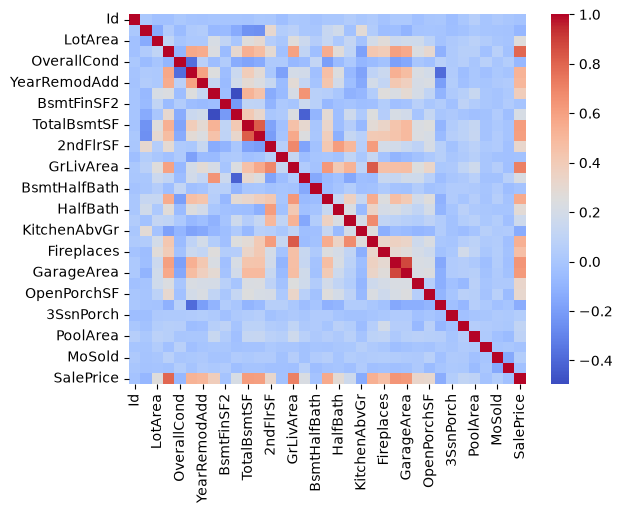

In [ ]:
corr=df_train.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')

In [ ]:
fig, ax = plt.subplots()
for c in df_train.colummns():
    df_train[c].hist(alpha=0.5, label=c, ax=ax)
    ax_set.title(c)
    plt.show()